In [1]:
from pathlib import Path

import torch as tc
import torchvision.transforms.v2 as tvs
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm

from models import ScatNet

# FIXME: remove transforms from validation and testing subsets
train_transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToImage(),
    tvs.ToDtype(tc.float32, scale=True),
    # bit of data augmentation
    # tvs.RandomRotation(360, interpolation="bilinear"),
    # tvs.RandomVerticalFlip(),
    tvs.RandomHorizontalFlip(),
    tvs.GaussianNoise(sigma=0.05),
    # tvs.Resize(100),
    tvs.RandomResizedCrop(100, scale=(0.8, 1)),
    # tvs.RandomCrop((224 // 2, 224 // 2)),
    tvs.Normalize(mean=(0.5,), std=(0.5,)),
])
test_transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToImage(),
    tvs.ToDtype(tc.float32, scale=True),
    tvs.Resize(100),
    tvs.CenterCrop(100),
    tvs.Normalize(mean=(0.5,), std=(0.5,)),
])

# same data sources but with different data transforms
augmented_data_source = ImageFolder("data/cats_and_dogs/PetImages", transform=train_transforms)
original_data_source = ImageFolder("data/cats_and_dogs/PetImages", transform=test_transforms)
SHAPE = (1, 100, 100)

In [2]:
%%script echo Skip
from torchvision.utils import make_grid
from pathlib import Path
import matplotlib.pyplot as plt

CATS = [i for i in range(10)]
DOGS = [i + 13000 for i in range(10)]
cat_examples = tc.stack([augmented_data_source[i][0] for i in CATS])
dog_examples = tc.stack([augmented_data_source[i][0] for i in DOGS])


grid = make_grid(cat_examples, nrow=20)
fig, axes = plt.subplots(nrows=2, figsize=(20, 20))
axes[0].imshow(make_grid(cat_examples, nrow=20).movedim(0, -1), cmap="gray")
axes[0].set_axis_off()
axes[1].imshow(make_grid(dog_examples, nrow=20).movedim(0, -1), cmap="gray")
axes[1].set_axis_off()


Couldn't find program: 'echo'


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import numpy as np


EPOCHS: int = 20
BATCH_SIZE: int = 500
WORKERS: int = 4
WEIGHT_SAVE_PATH = Path("weights/")

device = tc.device("cuda")

devel_indices, test_indices = train_test_split(np.arange(len(augmented_data_source.targets)), stratify=augmented_data_source.targets, random_state=0)
# devel_dataset, test_dataset = tc.utils.data.random_split(augmented_data_source, [0.8, 0.2], generator=RNG)


# required input for sklearn folds
y_dummy = np.array(augmented_data_source.targets)[devel_indices]
X_dummy = np.zeros_like(y_dummy)

folds = StratifiedKFold(n_splits=5)
fold_metrics: dict[int, dict] = {}
for fold_index, (train_indices, valid_indices) in enumerate(folds.split(X_dummy, y_dummy)):
    model = ScatNet(shape=SHAPE).to(device)

    i0 = np.concat([devel_indices[train_indices], devel_indices[valid_indices]])
    igt = devel_indices
    assert all(np.sort(i0) == np.sort(igt))

    # apply weight decay only to convolution layers
    decaying = []
    not_decaying = []
    for m in model.modules():
        if isinstance(m, (tc.nn.Linear, tc.nn.Conv2d)):
            decaying.append(m.weight)
            not_decaying.append(m.bias)
        elif hasattr(m, 'weight'):
            not_decaying.append(m.weight)
        elif hasattr(m, 'bias'):
            not_decaying.append(m.bias)

    grouped_parameters = [
        {"params": decaying, "weight_decay": 0.01},
        {"params": not_decaying, "weight_decay": 0.0}
    ]

    criterion = tc.nn.BCEWithLogitsLoss().to(device)
    optimizer = tc.optim.AdamW(grouped_parameters, lr=0.01)
    # scheduler = tc.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


    train_loader = DataLoader(
        tc.utils.data.Subset(augmented_data_source, devel_indices[train_indices]),
        shuffle=True,
        batch_size=BATCH_SIZE,
        num_workers=WORKERS,
        pin_memory=True,
    )
    valid_loader = DataLoader(
        tc.utils.data.Subset(original_data_source, devel_indices[valid_indices]),
        shuffle=True,
        batch_size=BATCH_SIZE,
        num_workers=WORKERS,
        pin_memory=True,
    )

    acc_train = []; f1_train = []; loss_train = []
    acc_valid = []; f1_valid = []; loss_valid = []
    for epoch in range(EPOCHS):
        print(f"Fold {fold_index} | Epoch: {epoch + 1}")

        # training phase
        running_loss = []
        running_acc = []
        running_f1 = []
        model.train()
        for images, labels in tqdm(train_loader, "Train on batches"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images).squeeze(dim=-1)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()

            # Compute accuracy, and F1-score
            # predicted = tc.argmax(outputs, dim=-1)
            predicted = tc.sigmoid(outputs).round().detach()
            running_loss.append(loss.item())
            running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
            running_f1.append(f1_score(labels.cpu(), predicted.cpu(), average="weighted"))
            # print("Batch accuracy score", accuracy_score(labels.cpu(), predicted.cpu()))

        loss_train.append(np.mean(running_loss))
        acc_train.append(np.mean(running_acc))
        f1_train.append(np.mean(running_f1))

        print(f"Train - Loss: {loss_train[epoch]:.4f}, Acc: {acc_train[epoch]:.4f}, F1: {f1_train[epoch]:.4f}")

        # validation phase
        model.eval()
        running_loss = []
        running_acc = []
        running_f1 = []
        with tc.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images).squeeze(dim=-1)
                loss = criterion(outputs, labels.float())

                # predicted = tc.argmax(outputs, dim=-1)
                predicted = tc.sigmoid(outputs).round().detach()
                running_loss.append(loss.item())
                running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
                running_f1.append(
                    f1_score(labels.cpu(), predicted.cpu(), average="weighted")
                )

            loss_valid.append(np.mean(running_loss))
            acc_valid.append(np.mean(running_acc))
            f1_valid.append(np.mean(running_f1))

            print(f"Valid - Loss: {loss_valid[epoch]:.4f}, Acc: {acc_valid[epoch]:.4f}, F1: {f1_valid[epoch]:.4f}")
            # save best state
            if f1_valid[-1] > max(f1_valid[:-1], default=-1):
                tc.save(model.state_dict(), Path(WEIGHT_SAVE_PATH, f"{model.name}_fold{fold_index}_best.pt"))

        # bookkeping
        # scheduler.step()

    fold_metrics[fold_index] =  {
        "train-loss": loss_train,
        "train-accuracy": acc_train,
        "train-f1-score": f1_train,
        "valid-loss": loss_valid,
        "valid-accuracy": acc_valid,
        "valid-f1-score": f1_valid,
    }

    # save last state
    tc.save(model.state_dict(), Path(WEIGHT_SAVE_PATH, f"{model.name}_fold{fold_index}_last.pt"))

Fold 0 | Epoch: 1


Train on batches: 100%|██████████| 30/30 [00:18<00:00,  1.63it/s]


Train - Loss: 0.6812, Acc: 0.5708, F1: 0.5102
Valid - Loss: 0.6046, Acc: 0.6710, F1: 0.6706


RuntimeError: Parent directory .weights does not exist.

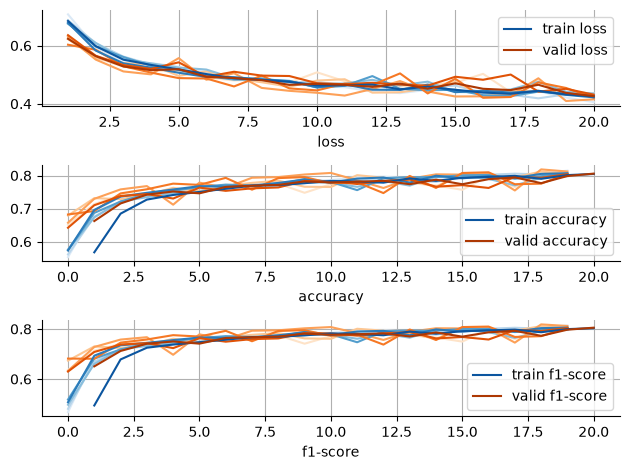

In [ ]:
# plot metrics traces
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3)

axes[0].set_xlabel("epoch")
axes[0].set_xlabel("loss")
axes[0].grid()
sns.despine(ax=axes[0])

axes[1].set_xlabel("epoch")
axes[1].set_xlabel("accuracy")
axes[1].grid()
axes[1].set_ybound(upper=1)
sns.despine(ax=axes[1])

axes[2].set_xlabel("epoch")
axes[2].set_xlabel("f1-score")
axes[2].grid()
axes[2].set_ybound(upper=1)
sns.despine(ax=axes[2])


epochs = np.arange(1, 1 + EPOCHS, dtype=int)
train_palette = sns.color_palette("Blues")
valid_palette = sns.color_palette("Oranges")
for fold, metrics in fold_metrics.items():
    train_color = train_palette[fold]
    valid_color = valid_palette[fold]
    sns.lineplot(x=epochs, y=metrics["train-loss"], ax=axes[0], color=train_color)
    sns.lineplot(x=epochs, y=metrics["valid-loss"], ax=axes[0], color=valid_color)

    sns.lineplot(metrics["train-accuracy"], ax=axes[1], color=train_color)
    sns.lineplot(metrics["valid-accuracy"], ax=axes[1], color=valid_color)

    sns.lineplot(metrics["train-f1-score"], ax=axes[2], color=train_color)
    sns.lineplot(metrics["valid-f1-score"], ax=axes[2], color=valid_color)

# average metrics across folds
mean_train_loss = np.mean(np.stack([x["train-loss"] for x in fold_metrics.values()]), axis=0)
mean_valid_loss = np.mean(np.stack([x["valid-loss"] for x in fold_metrics.values()]), axis=0)
sns.lineplot(x=epochs, y=mean_train_loss, ax=axes[0], label="train loss", color=train_palette[-1])
sns.lineplot(x=epochs, y=mean_valid_loss, ax=axes[0], label="valid loss", color=valid_palette[-1])

mean_train_acc = np.mean(np.stack([x["train-accuracy"] for x in fold_metrics.values()]), axis=0)
mean_valid_acc = np.mean(np.stack([x["valid-accuracy"] for x in fold_metrics.values()]), axis=0)
sns.lineplot(x=epochs, y=mean_train_acc, ax=axes[1], label="train accuracy", color=train_palette[-1])
sns.lineplot(x=epochs, y=mean_valid_acc, ax=axes[1], label="valid accuracy", color=valid_palette[-1])

mean_train_f1s = np.mean(np.stack([x["train-f1-score"] for x in fold_metrics.values()]), axis=0)
mean_valid_f1s = np.mean(np.stack([x["valid-f1-score"] for x in fold_metrics.values()]), axis=0)
sns.lineplot(x=epochs, y=mean_train_f1s, ax=axes[2], label="train f1-score", color=train_palette[-1])
sns.lineplot(x=epochs, y=mean_valid_f1s, ax=axes[2], label="valid f1-score", color=valid_palette[-1])

plt.tight_layout()
plt.savefig(f"images/{model.name}_metrics.png")
plt.show()

Test Accuracy: 0.8107, Test F1-score: 0.8106
Test Accuracy: 0.8038, Test F1-score: 0.8032
Test Accuracy: 0.7984, Test F1-score: 0.7983
Test Accuracy: 0.7944, Test F1-score: 0.7943
Test Accuracy: 0.8038, Test F1-score: 0.8038


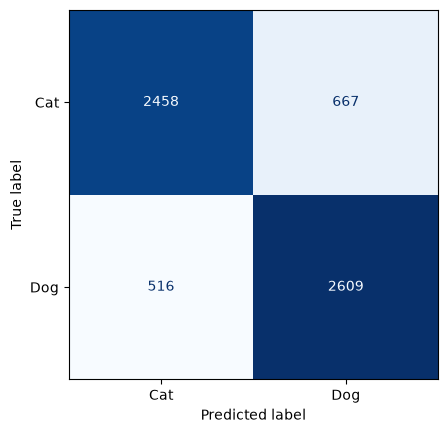

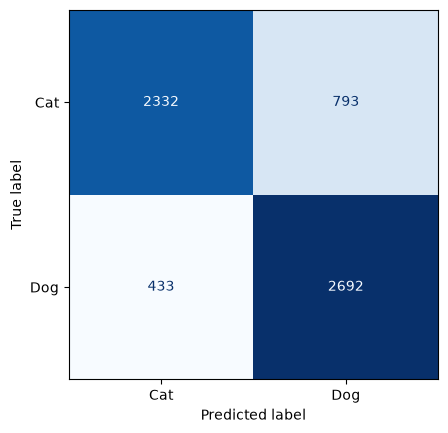

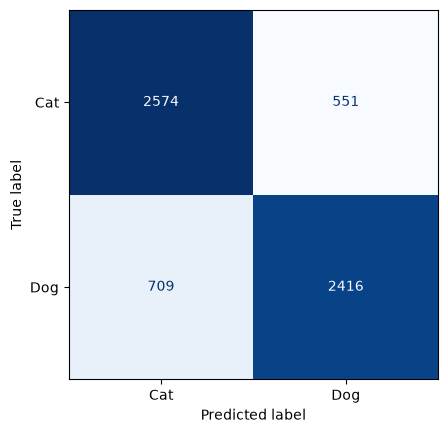

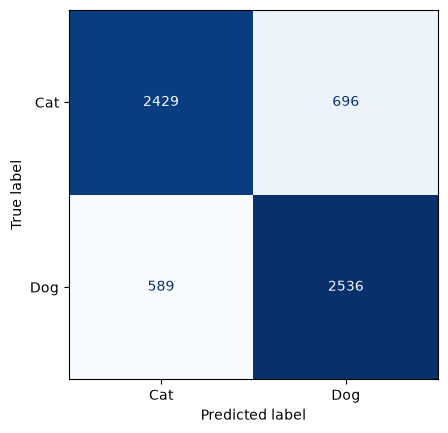

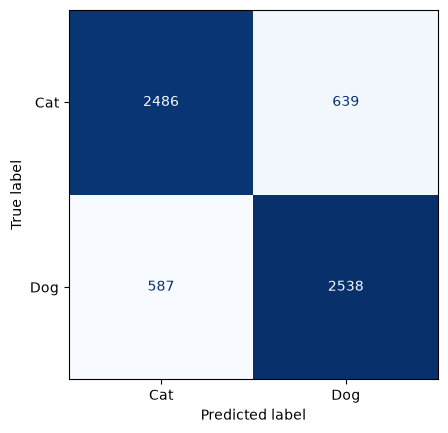

In [ ]:
# test the model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_loader = DataLoader(
    tc.utils.data.Subset(original_data_source, test_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
    pin_memory=True,
)

def test_model(model: tc.nn.Module, loader: DataLoader):
    model.eval()
    test_pred_labels = []
    test_true_labels = []
    with tc.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(dim=-1)
            # predicted = tc.argmax(outputs, dim=-1)
            predicted = tc.sigmoid(outputs).round().detach()
            test_pred_labels.extend(predicted.cpu().numpy())
            test_true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(test_true_labels, test_pred_labels)
    f1 = f1_score(test_true_labels, test_pred_labels, average='weighted')
    print(f'Test Accuracy: {accuracy:.4f}, Test F1-score: {f1:.4f}')

    cm = confusion_matrix(test_true_labels, test_pred_labels)
    cmd = ConfusionMatrixDisplay(cm, display_labels=original_data_source.classes)
    cmd.plot(cmap=plt.cm.Blues, colorbar=False)


for fold_index in range(folds.get_n_splits()):
    model = ScatNet(SHAPE).to(device)
    model.load_state_dict(tc.load(Path(WEIGHT_SAVE_PATH, f"{model.name}_fold{fold_index}_best.pt")))
    test_model(model, test_loader)